In [95]:
import yfinance as yf
import pandas as pd
import lxml

In [96]:
names = pd.read_csv("List_of_S%26P_500_companies_1.csv")
names.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [97]:
symbols = names['Symbol']
infors = []

for symb in symbols:
    infors.append(yf.Ticker(symb).info)

In [98]:
newdf = pd.DataFrame(infors)

In [99]:
featdf = newdf[['52WeekChange', 'trailingPE', 'marketCap', 'beta']]
featdf.head(10)

,52WeekChange,trailingPE,marketCap,beta
0,0.225712,25.321665,8.002153e+10,1.158
1,0.050397,16.963636,9.031715e+09,1.346
2,-0.254677,27.067226,1.679123e+11,0.782
3,0.224612,86.529410,3.642589e+11,0.364
4,-0.292161,16.120491,1.210376e+11,1.236
5,-0.287775,14.461859,1.011614e+11,1.518
6,2.253740,104.862595,4.479391e+11,1.963
7,0.476531,11.053435,1.032528e+10,1.008
8,0.090978,16.835285,6.026524e+10,0.652
9,0.215540,26.596025,NaN,1.303


In [100]:
featdf.isnull().sum()

52WeekChange     3
trailingPE      31
marketCap        3
beta             6
dtype: int64

In [101]:
featdf = featdf.dropna()
featdf.isnull().sum()

52WeekChange    0
trailingPE      0
marketCap       0
beta            0
dtype: int64

In [102]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [103]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(featdf)

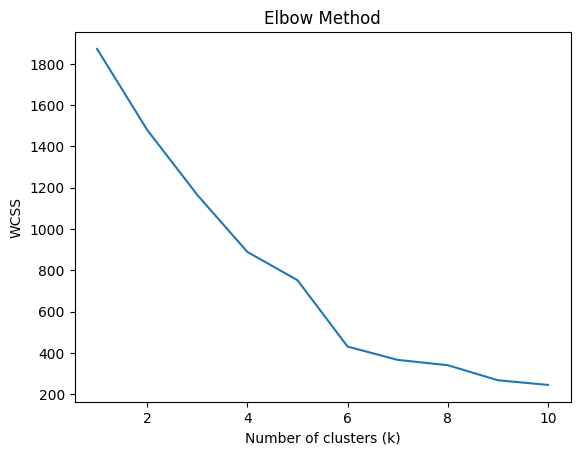

In [104]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
 
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [105]:
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

In [106]:
featdf['Cluster'] = clusters

In [107]:
featdf.groupby('Cluster').mean()

,52WeekChange,trailingPE,marketCap,beta
Cluster,,,,
0,0.293087,33.277296,7.300614e+10,1.185502
1,0.825013,38.058405,3.295198e+12,1.344000
2,0.141575,27.728323,9.033785e+10,0.565931
3,8.639332,169.303451,1.572553e+11,1.563667
4,1.383630,109.374102,1.636779e+11,1.902406
5,-0.489526,1972.000000,1.671557e+10,0.920000


In [108]:
featdf['Symbols'] = symbols

In [109]:
featdf[featdf['Cluster'] == 0].sort_values(by='marketCap', ascending=False)


,52WeekChange,trailingPE,marketCap,beta,Cluster,Symbols
270,0.355037,15.058908,8.480279e+11,1.043,0,JPM
353,0.425338,31.380608,5.027041e+11,1.597,0,ORCL
133,0.043977,52.156250,4.444908e+11,0.978,0,COST
330,-0.014991,30.362461,3.961232e+11,1.669,0,NFLX
58,0.460184,13.332090,3.829743e+11,1.237,0,BAC
...,...,...,...,...,...,...
1,0.050397,16.963636,9.031715e+09,1.346,0,AOS
413,0.038922,22.655174,8.893506e+09,1.300,0,SWKS
371,-0.232466,21.162064,8.454577e+09,1.262,0,POOL
325,-0.096691,14.102941,7.620374e+09,0.962,0,MOS


In [110]:
featdf[featdf['Cluster'] == 1].sort_values(by='marketCap', ascending=False)


,52WeekChange,trailingPE,marketCap,beta,Cluster,Symbols
344,1.081106,40.589794,4.834021e+12,2.335,1,NVDA
19,1.313808,31.368990,4.098284e+12,1.128,1,GOOGL
20,1.264781,31.086336,4.072637e+12,1.128,1,GOOG
38,0.398996,34.508236,4.001804e+12,1.109,1,AAPL
316,0.177294,26.152693,3.106140e+12,1.107,1,MSFT
22,0.497490,34.437935,2.655440e+12,1.383,1,AMZN
73,1.445942,77.669930,1.885462e+12,1.253,1,AVGO
310,0.420687,28.653324,1.707801e+12,1.309,1,META


In [111]:
featdf[featdf['Cluster'] == 2].sort_values(by='marketCap', ascending=False)


,52WeekChange,trailingPE,marketCap,beta,Cluster,Symbols
481,0.379721,46.915752,1.021105e+12,0.661,2,WMT
289,0.133261,40.289474,8.290156e+11,0.504,2,LLY
192,0.390033,22.192251,6.189532e+11,0.288,2,XOM
475,-0.009622,29.415972,6.040164e+11,0.799,2,V
268,0.492353,21.122393,5.614582e+11,0.329,2,JNJ
...,...,...,...,...,...,...
47,0.238701,13.458924,1.133774e+10,0.560,2,AIZ
266,-0.086890,22.107758,1.113667e+10,0.718,2,JKHY
82,-0.066871,29.429379,1.091041e+10,0.848,2,CPT
194,-0.436530,15.055948,8.685679e+09,0.724,2,FDS


In [112]:
featdf[featdf['Cluster'] == 3].sort_values(by='marketCap', ascending=False)


,52WeekChange,trailingPE,marketCap,beta,Cluster,Symbols
315,5.818550,20.811520,4.977957e+11,1.606,3,MU
490,9.359288,35.242912,1.274840e+11,1.829,3,WDC
408,6.409036,60.679817,1.205772e+11,1.634,3,STX
105,7.772994,319.420380,7.094251e+10,1.017,3,CIEN
117,5.619724,326.769230,6.371383e+10,1.905,3,COHR
296,16.856401,252.896850,6.301835e+10,1.391,3,LITE


In [113]:
featdf[featdf['Cluster'] == 4].sort_values(by='marketCap', ascending=False)

,52WeekChange,trailingPE,marketCap,beta,Cluster,Symbols
439,0.760967,363.231350,1.472041e+12,1.915,4,TSLA
6,2.253740,104.862595,4.479391e+11,1.963,4,AMD
90,1.790792,42.250530,3.723140e+11,1.519,4,CAT
357,0.612225,229.428560,3.456928e+11,1.674,4,PLTR
284,3.289149,53.983390,3.302092e+11,1.790,4,LRCX
39,1.928150,40.153687,3.110157e+11,1.637,4,AMAT
279,1.885696,52.040695,2.352186e+11,1.435,4,KLAC
45,1.426925,60.660587,2.092866e+11,1.475,4,ANET
40,1.091790,48.082832,1.628233e+11,2.502,4,APP
129,3.038821,91.368126,1.428456e+11,1.053,4,GLW


In [114]:
featdf[featdf['Cluster'] == 5].sort_values(by='marketCap', ascending=False)

,52WeekChange,trailingPE,marketCap,beta,Cluster,Symbols
132,-0.489526,1972.0,1.671557e+10,0.92,5,CSGP
